# 08 — Mechanism Evidence


In [2]:
import os, math, json, shutil, time, pickle
from dataclasses import dataclass, field
from collections import defaultdict
from typing import List, Dict, Optional
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
torch.manual_seed(42); np.random.seed(42)

# === Publication-grade matplotlib style ===
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.4,
    "lines.markersize": 5,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.04,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Consistent palette across all 5 notebooks.
COLORS = {
    "softmax":  "#C0392B",   # red
    "sigmoid":  "#27AE60",   # green
    "neutral":  "#2C3E50",   # near-black
    "grey":     "#7F8C8D",
    "lightgrey":"#BDC3C7",
    "yellow":   "#F39C12",
    "blue":     "#2980B9",
    "purple":   "#8E44AD",
}

def style_for(spec):
    """Return (color, linestyle, marker, label) for a model spec tuple
    (name, display, use_rope, use_sigmoid, gated)."""
    _, display, use_rope, use_sigmoid, _ = spec
    color = COLORS["sigmoid"] if use_sigmoid else COLORS["softmax"]
    ls    = "-" if use_rope else "--"
    mk    = "o" if use_rope else "s"
    return color, ls, mk, display


Mounted at /content/drive
Device: cuda


In [3]:
@dataclass
class Config:
    d_model: int = 768
    n_layer: int = 12
    n_head: int = 12
    d_ff: int = 3072
    block_size: int = 512
    vocab_size: int = 50257
    rope_base: float = 10000.0
    use_rope: bool = True       # toggled per spec
    use_sigmoid: bool = False   # toggled per spec

cfg_base = Config()

BASE       = "/content/drive/MyDrive/SigEvict"
DATA_DIR   = f"{BASE}/data"
MODEL_DIR  = f"{BASE}/models"
RESULT_DIR = f"{BASE}/results"
FIG_DIR    = f"{BASE}/figures"
TBL_DIR    = f"{BASE}/tables"
for d in [RESULT_DIR, FIG_DIR, TBL_DIR]: os.makedirs(d, exist_ok=True)

# 2 x 2 x 2 factorial: (attention) x (gate) x (position)
MODEL_SPECS = [
    # name                                  display          use_rope use_sigmoid gated
    ("gpt2_12L_dense_softmax",              "SM RoPE",         True,    False,   False),
    ("gpt2_12L_softmax_gated",              "SM+G RoPE",       True,    False,   True ),
    ("gpt2_12L_sigmoid_no_gate",            "Sig RoPE",        True,    True,    False),
    ("gpt2_12L_sigmoid_gated",              "Sig+G RoPE",      True,    True,    True ),
    ("gpt2_12L_dense_softmax_norope",       "SM NoPE",         False,   False,   False),
    ("gpt2_12L_softmax_gated_norope",       "SM+G NoPE",       False,   False,   True ),
    ("gpt2_12L_sigmoid_no_gate_norope",     "Sig NoPE",        False,   True,    False),
    ("gpt2_12L_sigmoid_gated_norope",       "Sig+G NoPE",      False,   True,    True ),
]
GATED_SPECS = [s for s in MODEL_SPECS if s[4]]
DENSE_SPECS = [s for s in MODEL_SPECS if not s[4]]
print(f"Registered {len(MODEL_SPECS)} models ({len(GATED_SPECS)} gated, {len(DENSE_SPECS)} dense)")

# Smoke toggle
SMOKE = False


Registered 8 models (4 gated, 4 dense)


## Model definitions (unified across all 8 specs)


In [4]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps, self.weight = eps, nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x / torch.sqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

class RotaryEmbedding(nn.Module):
    def __init__(self, dim, max_len=2048, base=10000.0):
        super().__init__()
        self.register_buffer("inv_freq", 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim)))
    def forward(self, seq_len, device):
        t = torch.arange(seq_len, device=device).float()
        freqs = torch.outer(t, self.inv_freq)
        emb = torch.cat([freqs, freqs], dim=-1)
        return emb.cos(), emb.sin()

def apply_rope(x, cos, sin, offset=0):
    d = x.shape[-1] // 2
    T = x.shape[2]
    x1, x2 = x[..., :d], x[..., d:]
    c = cos[offset:offset+T].unsqueeze(0).unsqueeze(0)
    s = sin[offset:offset+T].unsqueeze(0).unsqueeze(0)
    return torch.cat([x1*c[...,:d] - x2*s[...,:d], x1*s[...,:d] + x2*c[...,:d]], dim=-1)

class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.fc = nn.Linear(cfg.d_model, cfg.d_ff, bias=False)
        self.proj = nn.Linear(cfg.d_ff, cfg.d_model, bias=False)
    def forward(self, x): return self.proj(F.gelu(self.fc(x)))


In [5]:
class SoftmaxAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.n_head, self.d_head = cfg.n_head, cfg.d_model // cfg.n_head
        self.scale = 1.0 / math.sqrt(self.d_head)
        self.c_attn = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=False)
        self.c_proj = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.q_norm, self.k_norm = RMSNorm(self.d_head), RMSNorm(self.d_head)
        if cfg.use_rope:
            self.rotary = RotaryEmbedding(self.d_head, cfg.block_size, cfg.rope_base)
        self.register_buffer("mask", torch.triu(torch.ones(cfg.block_size, cfg.block_size), diagonal=1).bool())

    def forward(self, x, kv_mask=None):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(T, x.device)
            q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        att = (q @ k.transpose(-2, -1)) * self.scale
        att = att.masked_fill(self.mask[:T, :T], float("-inf"))
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            att = att + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v = v * m
        att = F.softmax(att, dim=-1)
        return self.c_proj((att @ v).transpose(1, 2).contiguous().view(B, T, C))

    def forward_kv(self, x, kv_cache=None, kv_mask=None, start_pos=0):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(start_pos + T, x.device)
            q = apply_rope(q, cos, sin, offset=start_pos)
            k = apply_rope(k, cos, sin, offset=start_pos)
        if kv_cache is not None:
            k = torch.cat([kv_cache[0], k], dim=2)
            v = torch.cat([kv_cache[1], v], dim=2)
        T_full = k.size(2)
        att = (q @ k.transpose(-2, -1)) * self.scale
        causal = self.mask[start_pos:start_pos+T, :T_full]
        att = att.masked_fill(causal.unsqueeze(0).unsqueeze(0), float("-inf"))
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            att = att + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v_att = v * m
        else:
            v_att = v
        att = F.softmax(att, dim=-1)
        y = (att @ v_att).transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y), (k, v)


class SigmoidAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.n_head, self.d_head = cfg.n_head, cfg.d_model // cfg.n_head
        self.scale = 1.0 / math.sqrt(self.d_head)
        self.c_attn = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=False)
        self.c_proj = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.q_norm, self.k_norm = RMSNorm(self.d_head), RMSNorm(self.d_head)
        if cfg.use_rope:
            self.rotary = RotaryEmbedding(self.d_head, cfg.block_size, cfg.rope_base)
        self.register_buffer("mask", torch.triu(torch.ones(cfg.block_size, cfg.block_size), diagonal=1).bool())
        self.register_buffer("pos_bias", -torch.log(torch.arange(cfg.block_size, dtype=torch.float32) + 1))

    def forward(self, x, kv_mask=None):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(T, x.device)
            q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        logits = (q @ k.transpose(-2, -1)) * self.scale + self.pos_bias[:T].view(1, 1, T, 1)
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v = v * m
        attn = torch.sigmoid(logits.masked_fill(self.mask[:T, :T], -1e9)).masked_fill(self.mask[:T, :T], 0.0)
        return self.c_proj((attn @ v).transpose(1, 2).contiguous().view(B, T, C))

    def forward_kv(self, x, kv_cache=None, kv_mask=None, start_pos=0):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(C, dim=-1)
        q = q.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_head).transpose(1, 2)
        q, k = self.q_norm(q), self.k_norm(k)
        if self.cfg.use_rope:
            cos, sin = self.rotary(start_pos + T, x.device)
            q = apply_rope(q, cos, sin, offset=start_pos)
            k = apply_rope(k, cos, sin, offset=start_pos)
        if kv_cache is not None:
            k = torch.cat([kv_cache[0], k], dim=2)
            v = torch.cat([kv_cache[1], v], dim=2)
        T_full = k.size(2)
        logits = (q @ k.transpose(-2, -1)) * self.scale
        if T == 1:
            logits = logits + (-math.log(start_pos + 1))
        else:
            logits = logits + self.pos_bias[:T].view(1, 1, T, 1)
        if kv_mask is not None:
            m = kv_mask.unsqueeze(1)
            logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            v_att = v * m
        else:
            v_att = v
        causal = self.mask[start_pos:start_pos+T, :T_full]
        attn = torch.sigmoid(logits.masked_fill(causal.unsqueeze(0).unsqueeze(0), -1e9))
        attn = attn.masked_fill(causal.unsqueeze(0).unsqueeze(0), 0.0)
        y = (attn @ v_att).transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y), (k, v)


In [6]:
class Block(nn.Module):
    def __init__(self, cfg, attn_cls):
        super().__init__()
        self.ln1, self.attn = nn.LayerNorm(cfg.d_model), attn_cls(cfg)
        self.ln2, self.mlp = nn.LayerNorm(cfg.d_model), MLP(cfg)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        return x + self.mlp(self.ln2(x))
    def forward_kv(self, x, kv_cache=None, start_pos=0):
        attn_out, new_kv = self.attn.forward_kv(self.ln1(x), kv_cache=kv_cache, start_pos=start_pos)
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        return x, new_kv

class GatedBlock(nn.Module):
    def __init__(self, cfg, layer_idx, attn_cls):
        super().__init__()
        self.ln1, self.attn = nn.LayerNorm(cfg.d_model), attn_cls(cfg)
        self.ln2, self.mlp = nn.LayerNorm(cfg.d_model), MLP(cfg)
        self.has_gate = layer_idx < cfg.n_layer - 1
        if self.has_gate:
            self.gate = nn.Linear(cfg.d_model, 1, bias=True)
    def forward(self, x, kv_mask=None):
        x = x + self.attn(self.ln1(x), kv_mask=kv_mask)
        x = x + self.mlp(self.ln2(x))
        g = torch.sigmoid(self.gate(x)) if self.has_gate else None
        return x, g
    def forward_kv(self, x, kv_cache=None, kv_mask=None, start_pos=0):
        attn_out, new_kv = self.attn.forward_kv(self.ln1(x), kv_cache=kv_cache,
                                                kv_mask=kv_mask, start_pos=start_pos)
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        g = torch.sigmoid(self.gate(x)) if self.has_gate else None
        return x, new_kv, g


class GPT2Dense(nn.Module):
    def __init__(self, cfg, attn_cls):
        super().__init__()
        self.cfg = cfg
        self.wte = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.blocks = nn.ModuleList([Block(cfg, attn_cls) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.wte.weight = self.head.weight

    def forward(self, idx, targets=None):
        x = self.wte(idx)
        for b in self.blocks: x = b(x)
        logits = self.head(self.ln_f(x))
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None
        return logits, loss

    def prefill(self, idx):
        B, T = idx.shape
        x = self.wte(idx)
        caches = []
        for block in self.blocks:
            x, kv = block.forward_kv(x, kv_cache=None, start_pos=0)
            caches.append(kv)
        logits = self.head(self.ln_f(x))
        return logits, caches

    def decode_step(self, tok, pos, caches):
        x = self.wte(tok)
        new_caches = []
        for l, block in enumerate(self.blocks):
            x, kv = block.forward_kv(x, kv_cache=caches[l], start_pos=pos)
            new_caches.append(kv)
        return self.head(self.ln_f(x)).squeeze(1), new_caches


class GPT2Gated(nn.Module):
    def __init__(self, cfg, attn_cls):
        super().__init__()
        self.cfg = cfg
        self.wte = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.blocks = nn.ModuleList([GatedBlock(cfg, i, attn_cls) for i in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.wte.weight = self.head.weight

    def forward(self, idx, targets=None):
        x = self.wte(idx)
        kv_mask, gates = None, []
        for b in self.blocks:
            x, g = b(x, kv_mask=kv_mask)
            if g is not None: gates.append(g)
            kv_mask = g
        logits = self.head(self.ln_f(x))
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None
        budget = sum(g.mean() for g in gates) / len(gates) if gates else None
        return logits, loss, budget, gates

    def prefill(self, idx):
        B, T = idx.shape
        x = self.wte(idx)
        caches, cache_masks = [], []
        prev_mask = torch.ones(B, T, 1, device=idx.device)
        for block in self.blocks:
            x, kv, gate = block.forward_kv(x, kv_cache=None, kv_mask=prev_mask, start_pos=0)
            caches.append(kv); cache_masks.append(prev_mask)
            prev_mask = gate if gate is not None else torch.ones(B, T, 1, device=idx.device)
        return self.head(self.ln_f(x)), caches, cache_masks

    def decode_step(self, tok, pos, caches, cache_masks):
        B = tok.size(0)
        x = self.wte(tok)
        new_caches, new_cache_masks = [], []
        prev_gate_new = torch.ones(B, 1, 1, device=tok.device)
        for l, block in enumerate(self.blocks):
            kv_mask = torch.cat([cache_masks[l], prev_gate_new], dim=1)
            x, kv, gate = block.forward_kv(x, kv_cache=caches[l], kv_mask=kv_mask, start_pos=pos)
            new_caches.append(kv); new_cache_masks.append(kv_mask)
            prev_gate_new = gate if gate is not None else torch.ones(B, 1, 1, device=tok.device)
        return self.head(self.ln_f(x)).squeeze(1), new_caches, new_cache_masks


def build_model(spec):
    name, display, use_rope, use_sigmoid, gated = spec
    cfg = Config()
    cfg.use_rope = use_rope
    cfg.use_sigmoid = use_sigmoid
    attn_cls = SigmoidAttention if use_sigmoid else SoftmaxAttention
    model = GPT2Gated(cfg, attn_cls) if gated else GPT2Dense(cfg, attn_cls)
    return model, cfg

def load_model(spec, device=device):
    name = spec[0]
    ckpt = torch.load(f"{MODEL_DIR}/{name}.pt", map_location=device, weights_only=False)
    model, cfg = build_model(spec)
    missing, unexpected = model.load_state_dict(ckpt["model_state_dict"], strict=False)
    if missing or unexpected:
        print(f"  [warn] {name}: missing={len(missing)}, unexpected={len(unexpected)}")
    model = model.to(device).eval()
    best_tau = ckpt.get("best_tau", None)
    return model, cfg, best_tau


In [7]:
@torch.no_grad()
def extract_attn_and_gate(model, cfg, input_ids):
    """Walk the model block-by-block, returning per-layer head-averaged attention
    and per-layer per-position gate (only for gated models)."""
    B, T = input_ids.shape
    x = model.wte(input_ids)
    C = x.shape[-1]
    attn_maps, gate_vals = [], []
    kv_mask = None

    for block in model.blocks:
        attn_mod = block.attn
        h = block.ln1(x)
        q, k, v = attn_mod.c_attn(h).split(C, dim=-1)
        q = q.view(B, T, attn_mod.n_head, attn_mod.d_head).transpose(1, 2)
        k = k.view(B, T, attn_mod.n_head, attn_mod.d_head).transpose(1, 2)
        v = v.view(B, T, attn_mod.n_head, attn_mod.d_head).transpose(1, 2)
        q, k = attn_mod.q_norm(q), attn_mod.k_norm(k)
        if cfg.use_rope:
            cos, sin = attn_mod.rotary(T, x.device)
            q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)

        is_sigmoid = hasattr(attn_mod, "pos_bias")
        if is_sigmoid:
            logits = (q @ k.transpose(-2, -1)) * attn_mod.scale
            logits = logits + attn_mod.pos_bias[:T].view(1, 1, T, 1)
            if kv_mask is not None:
                logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            logits = logits.masked_fill(attn_mod.mask[:T, :T], -1e9)
            weights = torch.sigmoid(logits).masked_fill(attn_mod.mask[:T, :T], 0.0)
        else:
            logits = (q @ k.transpose(-2, -1)) * attn_mod.scale
            logits = logits.masked_fill(attn_mod.mask[:T, :T], float("-inf"))
            if kv_mask is not None:
                logits = logits + torch.log(kv_mask.squeeze(-1).unsqueeze(1).unsqueeze(2).clamp(min=1e-8))
            weights = F.softmax(logits, dim=-1)

        attn_maps.append(weights.float().cpu())

        if hasattr(block, "has_gate"):
            x, g = block(x, kv_mask=kv_mask)
            if g is not None:
                gate_vals.append(g.squeeze(-1).float().cpu())
            kv_mask = g
        else:
            x = block(x)

    return attn_maps, gate_vals


## Load test tokens


In [8]:
LOCAL = "/content/local_data"; os.makedirs(LOCAL, exist_ok=True)
src, dst = f"{DATA_DIR}/owt_test_1M.pt", f"{LOCAL}/owt_test_1M.pt"
if not os.path.exists(dst):
    print("Copying test tokens to local SSD...")
    shutil.copy(src, dst)
test_tokens = torch.load(dst, weights_only=True)
print(f"Test tokens: {len(test_tokens):,}")

T_PER_SEQ = 512
N_TEST = 20 if SMOKE else (len(test_tokens) - 1) // T_PER_SEQ
print(f"N_TEST = {N_TEST}  ({N_TEST * T_PER_SEQ:,} tokens for stat collection)")


Copying test tokens to local SSD...
Test tokens: 1,000,000
N_TEST = 1953  (999,936 tokens for stat collection)


## Collect per-layer gate values + attention row-sum stats


In [9]:
@torch.no_grad()
def mechanism_stats(model, cfg, tokens, n_seqs, T):
    L      = cfg.n_layer
    L_gate = L - 1
    # Per-layer accumulators
    gate_all = [[] for _ in range(L_gate)]   # list of (T,) numpy arrays
    rowsum_all = [[] for _ in range(L)]       # list of (T,) numpy arrays
    for si in range(n_seqs):
        s = si * T
        if s + T > len(tokens): break
        toks = tokens[s:s+T].unsqueeze(0).to(device)
        attns, gates = extract_attn_and_gate(model, cfg, toks)
        for li, a in enumerate(attns):
            row_sums = a[0].mean(0).sum(-1).cpu().numpy()  # head-avg, then sum over keys
            rowsum_all[li].append(row_sums)
        for li, g in enumerate(gates):
            gate_all[li].append(g[0].cpu().numpy())

    out = {
        "gate_per_layer": [np.concatenate(g) if g else np.array([]) for g in gate_all],
        "rowsum_per_layer": [np.concatenate(r) for r in rowsum_all],
    }
    return out

mech = {}
for spec in MODEL_SPECS:
    name, display = spec[0], spec[1]
    print(f">>> {display}")
    model, cfg, _ = load_model(spec)
    mech[name] = mechanism_stats(model, cfg, test_tokens, N_TEST, T_PER_SEQ)
    if mech[name]["gate_per_layer"][0].size > 0:
        b0 = mech[name]["gate_per_layer"][0]
        binr = ((b0 < 0.05) | (b0 > 0.95)).mean()
        print(f"   L0 gate: mean={b0.mean():.3f} bin_rate={binr*100:.1f}% n={len(b0)}")
    rs = mech[name]["rowsum_per_layer"][cfg.n_layer//2]
    print(f"   L_mid row-sum: mean={rs.mean():.3f}  std={rs.std():.3f}  CV={rs.std()/(rs.mean()+1e-8):.3f}")
    del model; torch.cuda.empty_cache()


>>> SM RoPE
   L_mid row-sum: mean=1.000  std=0.000  CV=0.000
>>> SM+G RoPE
   L0 gate: mean=0.159 bin_rate=0.8% n=999936
   L_mid row-sum: mean=1.000  std=0.000  CV=0.000
>>> Sig RoPE
   L_mid row-sum: mean=0.448  std=0.164  CV=0.365
>>> Sig+G RoPE
   L0 gate: mean=0.131 bin_rate=1.4% n=999936
   L_mid row-sum: mean=1.064  std=0.451  CV=0.424
>>> SM NoPE
   L_mid row-sum: mean=1.000  std=0.000  CV=0.000
>>> SM+G NoPE
   L0 gate: mean=0.068 bin_rate=14.4% n=999936
   L_mid row-sum: mean=1.000  std=0.000  CV=0.000
>>> Sig NoPE
   L_mid row-sum: mean=0.495  std=0.134  CV=0.271
>>> Sig+G NoPE
   L0 gate: mean=0.119 bin_rate=88.3% n=999936
   L_mid row-sum: mean=0.695  std=0.248  CV=0.357


## Compute aggregate metrics per layer


In [10]:
def metrics_per_layer(stats, cfg):
    """Return dict of (L_gate,) and (L,) arrays."""
    L      = cfg.n_layer
    L_gate = L - 1
    binarization = np.zeros(L_gate)
    gate_mean    = np.zeros(L_gate)
    gate_entropy = np.zeros(L_gate)
    for li in range(L_gate):
        g = stats["gate_per_layer"][li]
        if g.size == 0: continue
        binarization[li] = ((g < 0.05) | (g > 0.95)).mean()
        gate_mean[li]    = g.mean()
        p = np.clip(g, 1e-6, 1 - 1e-6)
        gate_entropy[li] = (-(p*np.log(p) + (1-p)*np.log(1-p))).mean()

    rowsum_cv   = np.zeros(L)
    rowsum_mean = np.zeros(L)
    for li in range(L):
        r = stats["rowsum_per_layer"][li]
        rowsum_mean[li] = r.mean()
        rowsum_cv[li]   = r.std() / (r.mean() + 1e-8)
    return {"binarization": binarization, "gate_mean": gate_mean,
            "gate_entropy": gate_entropy, "rowsum_cv": rowsum_cv,
            "rowsum_mean": rowsum_mean}

metrics = {name: metrics_per_layer(s, Config()) for name, s in mech.items()}


## Fig 2 — 4-panel mechanism figure


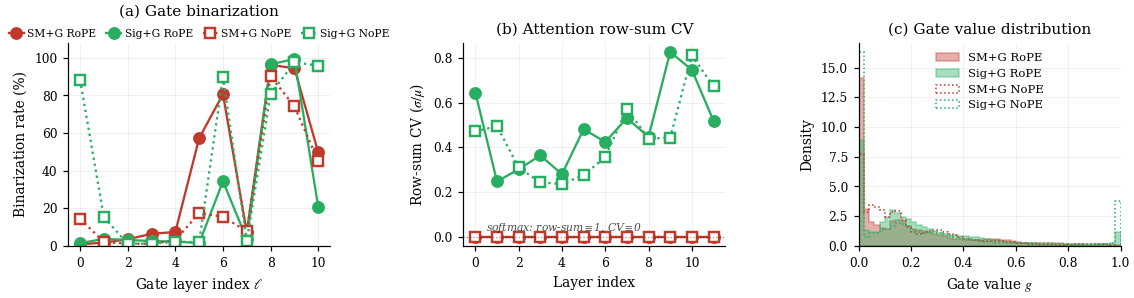

Saved /content/drive/MyDrive/SigEvict/figures/fig2_mechanism.{pdf,png}


In [11]:
# Visual encoding for line plots:
#   color  = attention type (red=softmax, green=sigmoid)
#   marker shape + line style + fill jointly encode PE
#     RoPE: solid line, filled circle
#     NoPE: dotted line, hollow square
def line_style(spec):
    """spec = (name, display, use_rope, use_sigmoid, gated)"""
    _, display, use_rope, use_sigmoid, _ = spec
    color = COLORS["sigmoid"] if use_sigmoid else COLORS["softmax"]
    if use_rope:
        return dict(color=color, ls="-",  marker="o", mfc=color, mec=color,
                    mew=1.4, ms=7, lw=1.5, label=display)
    else:
        return dict(color=color, ls=":",  marker="s", mfc="white", mec=color,
                    mew=1.6, ms=7, lw=1.5, label=display)

cfg = Config()
fig, axes = plt.subplots(1, 3, figsize=(10.5, 2.9))

GATED = [s for s in MODEL_SPECS if s[4]]

# (a) Binarization rate per layer
ax = axes[0]
for spec in GATED:
    name = spec[0]
    if name not in metrics: continue
    y = metrics[name]["binarization"] * 100
    ax.plot(range(len(y)), y, **line_style(spec))
ax.set_xlabel("Gate layer index $\\ell$")
ax.set_ylabel("Binarization rate (%)")
ax.set_title("(a) Gate binarization", fontsize=10, pad=18)   # +pad 给图例腾位置
ax.set_ylim(0, 108)
ax.grid(alpha=0.3, lw=0.4)
ax.legend(
    fontsize=7, loc="lower center", bbox_to_anchor=(0.5, 1.0),
    ncol=4, handlelength=1.4, columnspacing=0.9, handletextpad=0.35,
    borderaxespad=0.0, frameon=False,
)

# (b) Attention row-sum CV per layer (gated only; softmax constant annotated)
ax = axes[1]
for spec in GATED:
    name = spec[0]
    if name not in metrics: continue
    y = metrics[name]["rowsum_cv"]
    ax.plot(range(len(y)), y, **line_style(spec))
ax.axhline(0, color="black", ls=":", alpha=0.4, lw=0.8)
ax.text(0.5, 0.025, "softmax: row-sum$\\equiv$1, CV$\\equiv$0",
        fontsize=7, color="black", alpha=0.7, style="italic")
ax.set_xlabel("Layer index")
ax.set_ylabel("Row-sum CV ($\\sigma/\\mu$)")
ax.set_title("(b) Attention row-sum CV", fontsize=10)
ax.grid(alpha=0.3, lw=0.4)

# (c) Gate value density (gated only): RoPE filled, NoPE dotted outline
ax = axes[2]
for spec in GATED:
    name = spec[0]
    if name not in mech: continue
    g = np.concatenate(mech[name]["gate_per_layer"])
    color = COLORS["sigmoid"] if spec[3] else COLORS["softmax"]
    use_rope = spec[2]
    if use_rope:
        ax.hist(g, bins=50, range=(0, 1), density=True, alpha=0.4,
                color=color, label=spec[1], histtype="stepfilled",
                edgecolor=color, lw=1.4, linestyle="-")
    else:
        ax.hist(g, bins=50, range=(0, 1), density=True,
                color=color, label=spec[1], histtype="step",
                edgecolor=color, lw=1.8, linestyle=":")
ax.set_xlabel("Gate value $g$")
ax.set_ylabel("Density")
ax.set_title("(c) Gate value distribution", fontsize=10)
ax.set_xlim(0, 1)
ax.grid(alpha=0.3, lw=0.4)
ax.legend(fontsize=7.5, loc="upper center", framealpha=0.85)

plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(f"{FIG_DIR}/fig2_mechanism.{ext}", dpi=300)
plt.show()
print(f"Saved {FIG_DIR}/fig2_mechanism.{{pdf,png}}")


## Sup. Fig — gate histograms per layer (4 gated models)


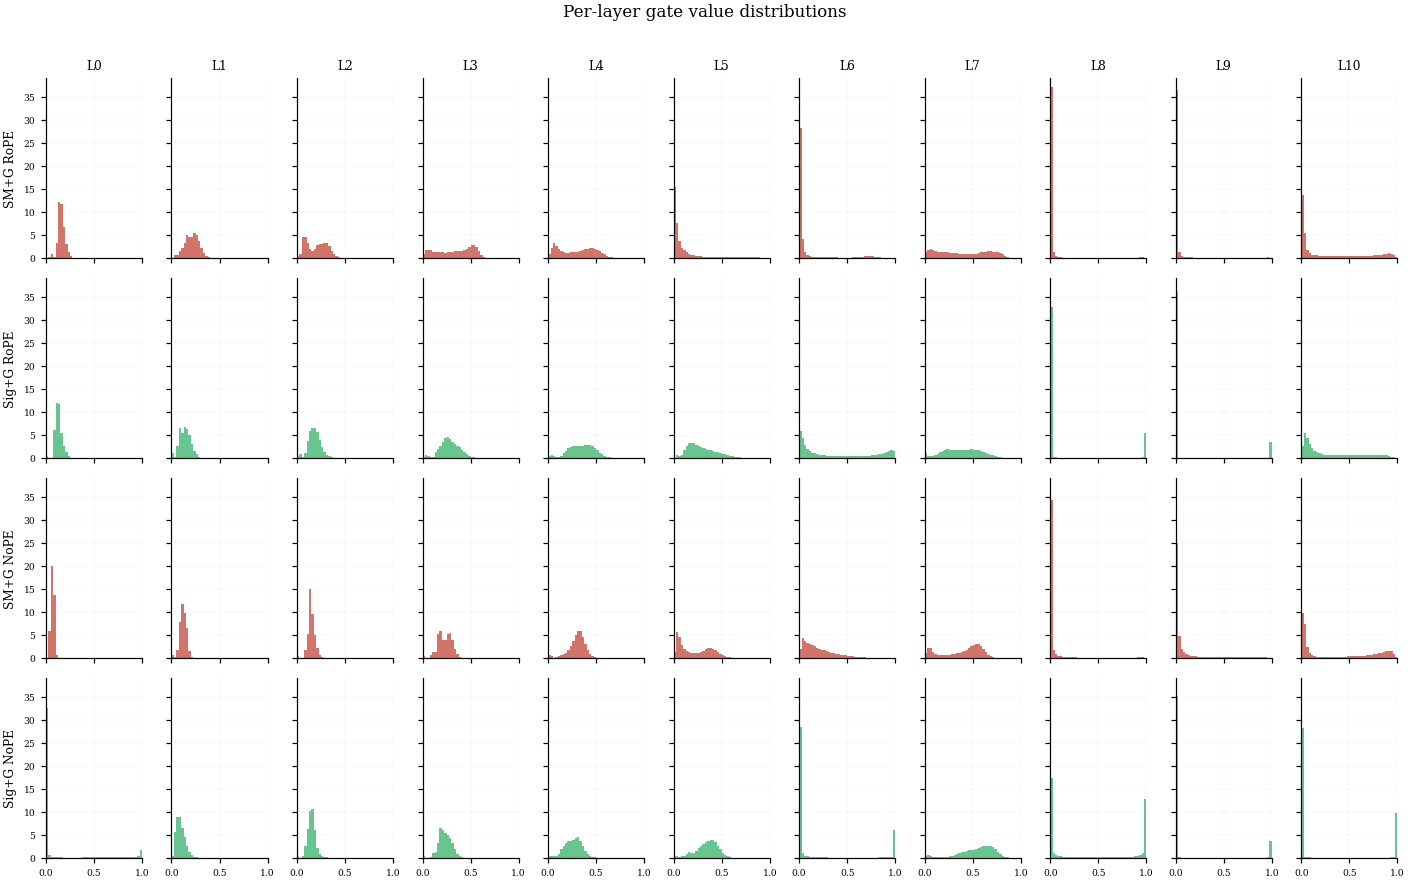

In [12]:
fig, axes = plt.subplots(len(GATED), cfg.n_layer-1, figsize=(13, 2*len(GATED)),
                          sharex=True, sharey=True)
for r_idx, spec in enumerate(GATED):
    name = spec[0]
    if name not in mech: continue
    color = COLORS["sigmoid"] if spec[3] else COLORS["softmax"]
    for li in range(cfg.n_layer - 1):
        g = mech[name]["gate_per_layer"][li]
        ax = axes[r_idx, li] if axes.ndim == 2 else axes[li]
        ax.hist(g, bins=40, range=(0,1), density=True, color=color, alpha=0.7,
                edgecolor="none")
        ax.set_xlim(0, 1)
        if r_idx == 0: ax.set_title(f"L{li}", fontsize=8)
        if li == 0: ax.set_ylabel(spec[1], fontsize=8)
        ax.tick_params(labelsize=6)
        ax.grid(alpha=0.2, lw=0.3)
plt.suptitle("Per-layer gate value distributions", fontsize=11, y=1.01)
plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(f"{FIG_DIR}/sup_gate_histograms.{ext}", dpi=300)
plt.show()


## Sup. Fig — attention row-sum distributions (all 8 models)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


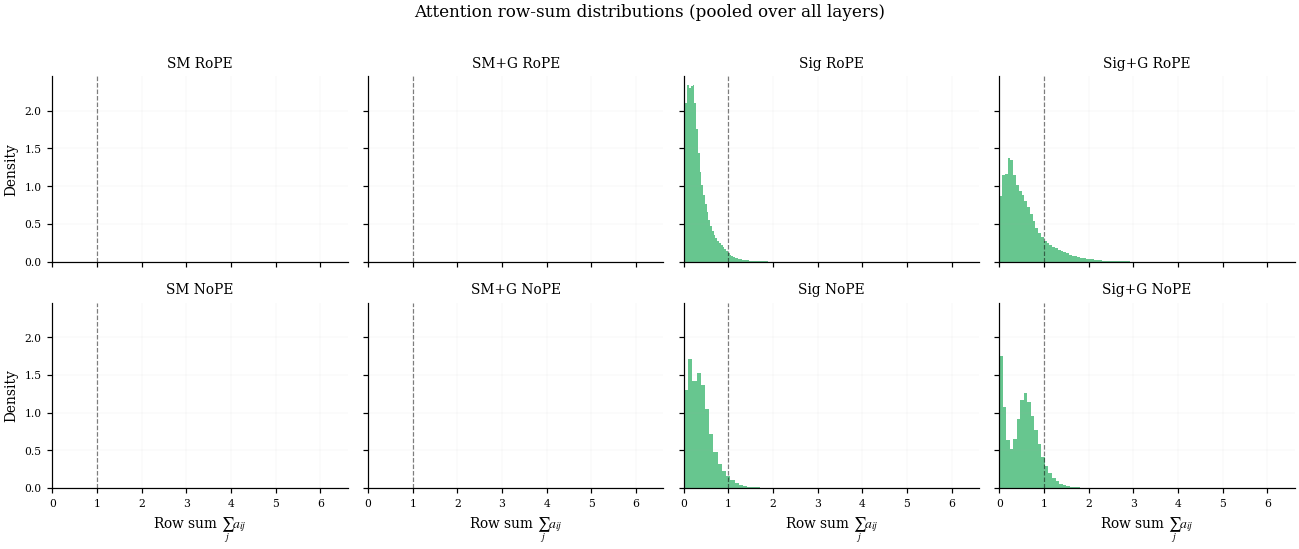

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(12, 5), sharex=True, sharey=True)
for ax, spec in zip(axes.flat, MODEL_SPECS):
    name = spec[0]
    if name not in mech: continue
    color = COLORS["sigmoid"] if spec[3] else COLORS["softmax"]
    # Pool row-sums across all layers
    pooled = np.concatenate(mech[name]["rowsum_per_layer"])
    ax.hist(pooled, bins=80, density=True, color=color, alpha=0.7, edgecolor="none")
    ax.axvline(1.0, color="black", ls="--", alpha=0.5, lw=0.8)
    ax.set_title(spec[1], fontsize=9)
    ax.set_xlim(0, max(pooled.max() * 1.05, 2.0))
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.2, lw=0.3)
for ax in axes[-1, :]: ax.set_xlabel("Row sum $\\sum_j a_{ij}$")
for ax in axes[:, 0]:  ax.set_ylabel("Density")
plt.suptitle("Attention row-sum distributions (pooled over all layers)", fontsize=11, y=1.01)
plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(f"{FIG_DIR}/sup_rowsum_distribution.{ext}", dpi=300)
plt.show()


## Mechanism summary table (LaTeX)


In [14]:
lines = [
    "% Mechanism table",
    "\\begin{tabular}{lcccc}",
    "\\toprule",
    "Model & avg binarization & avg entropy & avg gate $\\bar g$ & avg rowsum CV \\\\",
    "\\midrule",
]
for spec in MODEL_SPECS:
    name = spec[0]
    if name not in metrics: continue
    m = metrics[name]
    if spec[4]:
        bin_avg = m["binarization"].mean() * 100
        ent_avg = m["gate_entropy"].mean()
        gm      = m["gate_mean"].mean()
        gate_str = f"{bin_avg:.1f}\\% & {ent_avg:.3f} & {gm:.3f}"
    else:
        gate_str = "-- & -- & --"
    cv_avg = m["rowsum_cv"].mean()
    lines.append(f"{spec[1]} & {gate_str} & {cv_avg:.3f} \\\\")
lines += ["\\bottomrule", "\\end{tabular}"]
with open(f"{TBL_DIR}/table_mechanism.tex", "w") as f: f.write("\n".join(lines))
print("\n".join(lines))


% Mechanism table
\begin{tabular}{lcccc}
\toprule
Model & avg binarization & avg entropy & avg gate $\bar g$ & avg rowsum CV \\
\midrule
SM RoPE & -- & -- & -- & 0.000 \\
SM+G RoPE & 36.8\% & 0.342 & 0.195 & 0.000 \\
Sig RoPE & -- & -- & -- & 0.437 \\
Sig+G RoPE & 24.4\% & 0.392 & 0.245 & 0.484 \\
SM NoPE & -- & -- & -- & 0.000 \\
SM+G NoPE & 24.7\% & 0.375 & 0.197 & 0.000 \\
Sig NoPE & -- & -- & -- & 0.422 \\
Sig+G NoPE & 43.3\% & 0.301 & 0.251 & 0.444 \\
\bottomrule
\end{tabular}


## Support-removal sensitivity probe


>>> support-removal test on SM RoPE
   drop_frac=0.1  mean per-layer rel.pert. = 0.5737  (L0=0.3040  L_mid=0.6419  L_last=0.5673)
   drop_frac=0.3  mean per-layer rel.pert. = 0.9434  (L0=0.5373  L_mid=1.0556  L_last=0.9451)
   drop_frac=0.5  mean per-layer rel.pert. = 1.1309  (L0=0.7094  L_mid=1.2664  L_last=1.1279)
>>> support-removal test on Sig RoPE
   drop_frac=0.1  mean per-layer rel.pert. = 0.5790  (L0=0.3049  L_mid=0.7066  L_last=0.5742)
   drop_frac=0.3  mean per-layer rel.pert. = 1.0505  (L0=0.5363  L_mid=1.3013  L_last=1.0442)
   drop_frac=0.5  mean per-layer rel.pert. = 3.6660  (L0=0.6978  L_mid=3.5033  L_last=1.9016)


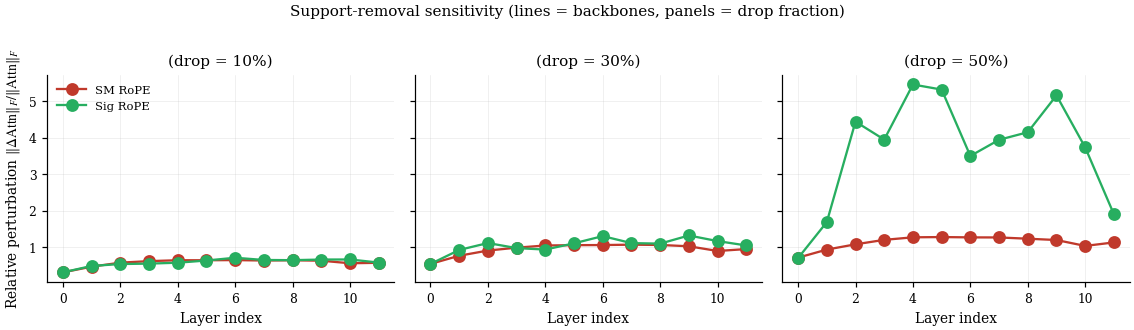


=== SUPPORT-REMOVAL SUMMARY ===

  drop_frac = 0.1:
    SM RoPE         mean rel.pert. = 0.5737
    Sig RoPE        mean rel.pert. = 0.5790

  drop_frac = 0.3:
    SM RoPE         mean rel.pert. = 0.9434
    Sig RoPE        mean rel.pert. = 1.0505

  drop_frac = 0.5:
    SM RoPE         mean rel.pert. = 1.1309
    Sig RoPE        mean rel.pert. = 3.6660


In [15]:
@torch.no_grad()
def attention_outputs_per_layer(model, cfg, idx, drop_idx_per_layer=None):
    """Walk model block-by-block and return per-layer attention output (the c_proj input,
    i.e. (att @ v) reshaped). Optionally drop K/V at the indices specified per layer.
    drop_idx_per_layer: dict {layer_idx: 1d LongTensor of indices to ZERO OUT in K/V}
    Returns: list of (B, T, C) attention outputs, one per layer."""
    B, T = idx.shape
    x = model.wte(idx)
    C = x.shape[-1]
    outputs = []
    for li, block in enumerate(model.blocks):
        am = block.attn
        h = block.ln1(x)
        q, k, v = am.c_attn(h).split(C, dim=-1)
        q = q.view(B, T, am.n_head, am.d_head).transpose(1, 2)
        k = k.view(B, T, am.n_head, am.d_head).transpose(1, 2)
        v = v.view(B, T, am.n_head, am.d_head).transpose(1, 2)
        q, k = am.q_norm(q), am.k_norm(k)
        if cfg.use_rope:
            cos, sin = am.rotary(T, x.device)
            q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        # Drop = mask K and V positions to zero (effectively removes them from attention)
        if drop_idx_per_layer is not None and li in drop_idx_per_layer:
            di = drop_idx_per_layer[li]
            keep_mask = torch.ones(T, dtype=torch.bool, device=x.device)
            keep_mask[di] = False
            k = k * keep_mask.view(1, 1, T, 1).float()
            v = v * keep_mask.view(1, 1, T, 1).float()
        is_sig = hasattr(am, "pos_bias")
        if is_sig:
            logits = (q @ k.transpose(-2, -1)) * am.scale + am.pos_bias[:T].view(1, 1, T, 1)
            logits = logits.masked_fill(am.mask[:T, :T], -1e9)
            # When K rows are zeroed, their logits remain finite (q @ 0 = 0); we additionally
            # mask them so dropped positions cannot receive attention mass under sigmoid either
            if drop_idx_per_layer is not None and li in drop_idx_per_layer:
                logits[..., drop_idx_per_layer[li]] = -1e9
            att = torch.sigmoid(logits).masked_fill(am.mask[:T, :T], 0.0)
        else:
            logits = (q @ k.transpose(-2, -1)) * am.scale
            logits = logits.masked_fill(am.mask[:T, :T], float("-inf"))
            if drop_idx_per_layer is not None and li in drop_idx_per_layer:
                logits[..., drop_idx_per_layer[li]] = float("-inf")
            att = F.softmax(logits, dim=-1)
        y = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
        outputs.append(y.float().cpu())
        # Run the rest of the block forward (with the unmodified attention) so x evolves correctly
        x = x + am.c_proj(y)
        x = x + block.mlp(block.ln2(x))
    return outputs

@torch.no_grad()
def support_removal_test(model, cfg, tokens, drop_fracs=(0.1, 0.3, 0.5),
                         n_seqs=20 if SMOKE else 50, T=512, seed=42):
    """For each sequence and each drop_frac, randomly drop that fraction of K/V positions
    in EVERY layer and measure the relative Frobenius perturbation of the layer's attention
    output. Report mean per-layer perturbation."""
    rng = np.random.default_rng(seed)
    L = cfg.n_layer
    perts = {f: np.zeros(L) for f in drop_fracs}   # accumulator
    counts = 0
    for si in range(n_seqs):
        s = si * T
        if s + T > len(tokens): break
        toks = tokens[s:s+T].unsqueeze(0).to(device)
        out_full = attention_outputs_per_layer(model, cfg, toks, drop_idx_per_layer=None)
        for f in drop_fracs:
            n_drop = int(round(f * T))
            # Sample drop positions from [4, T) (preserve first 4 as sinks for fairness)
            di_per_layer = {}
            for li in range(L):
                di_per_layer[li] = torch.from_numpy(
                    rng.choice(np.arange(4, T), size=n_drop, replace=False)
                ).long().to(device)
            out_drop = attention_outputs_per_layer(model, cfg, toks, drop_idx_per_layer=di_per_layer)
            for li in range(L):
                num = (out_full[li] - out_drop[li]).norm().item()
                den = out_full[li].norm().item() + 1e-8
                perts[f][li] += num / den
        counts += 1
    return {f: (perts[f] / counts).tolist() for f in drop_fracs}

# Run on the two non-gated dense backbones with same PE (RoPE) — clean comparison
sup_targets = [s for s in DENSE_SPECS if s[2] == True]   # SM RoPE and Sig RoPE
support_results = {}
for spec in sup_targets:
    name, display = spec[0], spec[1]
    print(f">>> support-removal test on {display}")
    model, cfg, _ = load_model(spec)
    support_results[name] = support_removal_test(model, cfg, test_tokens)
    for f, perts in support_results[name].items():
        print(f"   drop_frac={f:.1f}  mean per-layer rel.pert. = {np.mean(perts):.4f}  "
              f"(L0={perts[0]:.4f}  L_mid={perts[len(perts)//2]:.4f}  L_last={perts[-1]:.4f})")
    del model; torch.cuda.empty_cache()

# Visual encoding for line plots:
#   color  = attention type (red=softmax, green=sigmoid)
#   marker shape + line style + fill jointly encode PE
#     RoPE: solid line, filled circle
#     NoPE: dotted line, hollow square
def line_style(spec):
    """spec = (name, display, use_rope, use_sigmoid, gated)"""
    _, display, use_rope, use_sigmoid, _ = spec
    color = COLORS["sigmoid"] if use_sigmoid else COLORS["softmax"]
    if use_rope:
        return dict(color=color, ls="-",  marker="o", mfc=color, mec=color,
                    mew=1.4, ms=7, lw=1.5, label=display)
    else:
        return dict(color=color, ls=":",  marker="s", mfc="white", mec=color,
                    mew=1.6, ms=7, lw=1.5, label=display)

# Plot: split drop_fracs into separate panels so each panel has only |sup_targets| lines
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.0), sharey=True)
DROP_FRACS = [0.1, 0.3, 0.5]

for ax, f in zip(axes, DROP_FRACS):
    for spec in sup_targets:
        name = spec[0]
        if name not in support_results: continue
        if f not in support_results[name]: continue
        perts = support_results[name][f]
        ax.plot(range(len(perts)), perts, **line_style(spec))
    ax.set_xlabel("Layer index")
    ax.set_title(f"(drop = {int(f*100)}%)", fontsize=10)
    ax.grid(alpha=0.3, lw=0.4)

axes[0].set_ylabel("Relative perturbation $\\|\\Delta\\text{Attn}\\|_F / \\|\\text{Attn}\\|_F$")
axes[0].legend(fontsize=7.5, loc="upper left", handlelength=2.5, framealpha=0.85)

plt.suptitle("Support-removal sensitivity (lines = backbones, panels = drop fraction)",
             fontsize=10, y=1.02)
plt.tight_layout()
for ext in ["pdf", "png"]:
    plt.savefig(f"{FIG_DIR}/sup_support_removal.{ext}", dpi=300)
plt.show()

# Statistical summary
print("\n=== SUPPORT-REMOVAL SUMMARY ===")
for f in DROP_FRACS:
    vals = []
    for name in support_results:
        spec = next(s for s in MODEL_SPECS if s[0]==name)
        v = np.mean(support_results[name][f])
        vals.append((spec[1], v))
    vals.sort(key=lambda x: x[1])
    print(f"\n  drop_frac = {f:.1f}:")
    for disp, v in vals:
        print(f"    {disp:<14}  mean rel.pert. = {v:.4f}")


## Persist


In [16]:
import numpy as np
out = {}
for name, m in metrics.items():
    out[name] = {k: v.tolist() for k, v in m.items()}
out["_support_removal"] = {n: {str(f): vs for f, vs in r.items()}
                           for n, r in support_results.items()}
out["_config"] = {"n_seqs": N_TEST, "T_per_seq": T_PER_SEQ,
                  "binarization_thresholds": [0.05, 0.95], "split": "test",
                  "support_removal_drop_fracs": [0.1, 0.3, 0.5]}
with open(f"{RESULT_DIR}/mechanism_stats.json", "w") as f:
    json.dump(out, f, indent=2)
print(f"Saved {RESULT_DIR}/mechanism_stats.json")


Saved /content/drive/MyDrive/SigEvict/results/mechanism_stats.json
